In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import astropy.io.fits as fits
import astropy.units as u
import math
import pandas as pd
from mode_coupling_matrix import compute_mode_coupling_matrix_from_mask

In [3]:
# The code in this notebook reproduces Figure 12 from Nofi et al. (2025a)
# https://arxiv.org/abs/2509.03718

In [4]:
nside=128

In [5]:
# Final cleaned maps (named 'ELC') from final cleaning fit (Section 3.6)
final_70_map="../ELC_Maps/ELC_70GHz.fits"
final_70=hp.fitsfunc.read_map(final_70_map,field=[0])

final_94_map="../ELC_Maps/ELC_94GHz.fits"
final_94=hp.fitsfunc.read_map(final_94_map,field=[0])

final_100_map="../ELC_Maps/ELC_100GHz.fits"
final_100=hp.fitsfunc.read_map(final_100_map,field=[0])

final_143_map="../ELC_Maps/ELC_143GHz.fits"
final_143=hp.fitsfunc.read_map(final_143_map,field=[0])

In [6]:
# Baseline ΛCDM model from Planck 2018 release
df = pd.read_csv("COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt",delim_whitespace=True, header=None)
com_Dl = df.iloc[1:, 1].astype(float).to_numpy()
ell = np.arange(2, 2 + len(com_Dl))         
lmax= int(ell[-1])

# Convert to Cls
cl_tt = com_Dl / (ell * (ell + 1) / (2.0 * np.pi))

# File starts at ell=2, adjust to start at ell=0 to match the power spectra from maps
cl_tt_full = np.zeros(lmax + 1, dtype=np.float64)
cl_tt_full[2:] = cl_tt

/var/folders/3k/w31y20251nzbdg040fwmv7tc0000gn/T/ipykernel_7367/1954973168.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt",delim_whitespace=True, header=None)


In [7]:
# Import 0.5%, 1%, and 2% masks
mask_005p="../ELC_Masks/ELC_0.5percent_mask.fits"
mask_005p=hp.fitsfunc.read_map(mask_005p,field=[0])

mask_01p="../ELC_Masks/ELC_1percent_mask.fits"
mask_01p=hp.fitsfunc.read_map(mask_01p,field=[0])

mask_02p="../ELC_Masks/ELC_2percent_mask.fits"
mask_02p=hp.fitsfunc.read_map(mask_02p,field=[0])

In [8]:
# Set up dictionary with key names related to mask and map combination to make process smoother

mask_labels = ['005p', '01p', '02p']

map_labels = ['70', '100', '143', '94']

masks = [mask_005p, mask_01p, mask_02p]

maps = [final_143, final_100,final_94,final_70]

results = {}
for i, mask in enumerate(masks):
    for j, map_data in enumerate(maps):
        result_key = f"stdv_mask_{mask_labels[i]}_map_{map_labels[j]}"
        map_debias = (mask * map_data)*1000
        map_debias[np.isnan(map_debias)] = hp.UNSEEN
        results[result_key] = map_debias

In [9]:
# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude 
ell=np.arange(384)
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*ell*(ell+1)*beam_sigma_rad**2.)

In [10]:
# We use the mode-coupling matrix method to correct for the bias caused by setting pixels to zero 
# (for more detail see Section 3.1 Nofi et al. 2025b)
# 0.5% mask
mask_005p[mask_005p == 0] = hp.UNSEEN
# build the mode-coupling matrix from this mask (see mode_coupling_matrix.py)
M_005 = compute_mode_coupling_matrix_from_mask(mask_005p)
# Need the inverse matrix for the dot product correction
M_005p_inv = np.linalg.inv(M_005)

In [11]:
# 1% mask
mask_01p[mask_01p == 0] = hp.UNSEEN
# build the mode-coupling matrix from this mask (see mode_coupling_matrix.py)
M_01 = compute_mode_coupling_matrix_from_mask(mask_01p)
# Need the inverse matrix for the dot product correction
M_01p_inv = np.linalg.inv(M_01)

In [12]:
# 2% mask
mask_02p[mask_02p == 0] = hp.UNSEEN
# build the mode-coupling matrix from this mask (see mode_coupling_matrix.py)
M_02 = compute_mode_coupling_matrix_from_mask(mask_02p)
# Need the inverse matrix for the dot product correction
M_02p_inv = np.linalg.inv(M_02)

In [13]:
Cl_results_stdv = {} 
Debiased_results = {}  

for key, masked_map in results.items():
    key_parts = key.split('_')
    mask_label = key_parts[2]  # extract the mask part of key
    map_label = key_parts[4]   # extract the map part of key

    Cl_key = f"Cl_{map_label}_{mask_label}"
    # Compute the pseudo-Cl (uncorrected for mode-coupling) from the masked map using hp.anafast
    Cl_results_stdv[Cl_key] = hp.anafast(masked_map, lmax=3 * nside - 1, use_pixel_weights=True)

    M_inv_key = f"M_{mask_label}_inv"
    # Get the inverse mode-coupling matrix for this mask
    M_inv = globals()[M_inv_key]  
    
    test_key = f"test_{map_label}_{mask_label}"
    # Debiased_results stores the Cls corrected for mask-induced mode coupling and for beam and pixel window functions.
    # First dot the inverse mode-coupling matrix by the pseudo-Cl to correct mask bias
    # Then divide by beam window^2 and pixel window^2 to correct for beam and pixel smoothing
    Debiased_results[test_key] = np.dot(M_inv, Cl_results_stdv[Cl_key]) / (((wl_bl)**2) * hp.pixwin(128)**2) 

In [14]:
# Full-sky maps: compute power spectrum using hp.anafast and correct for beam and pixel windows
p143_Cl = hp.anafast(final_143*1000, lmax=3 * nside - 1, use_pixel_weights=True)
p143_Cl = p143_Cl / (((wl_bl)**2) * hp.pixwin(128)**2)
p100_Cl = hp.anafast(final_100*1000, lmax=3 * nside - 1, use_pixel_weights=True)
p100_Cl = p100_Cl / (((wl_bl)**2) * hp.pixwin(128)**2)
p70_Cl = hp.anafast(final_70*1000, lmax=3 * nside - 1, use_pixel_weights=True)
p70_Cl = p70_Cl / (((wl_bl)**2) * hp.pixwin(128)**2)
w94_Cl = hp.anafast(final_94*1000, lmax=3 * nside - 1, use_pixel_weights=True)
w94_Cl = w94_Cl / (((wl_bl)**2) * hp.pixwin(128)**2)

In [15]:
# Used to convert Cl differences to cosmic variance units
denom = np.sqrt(2.0 / (2.0 * ell + 1.0)) * cl_tt_full[:len(ell)]
# Range for plot (avoid divide by 0s)
valid = (ell >= 2) & (ell <= 30)

(-1.0, 1.0)

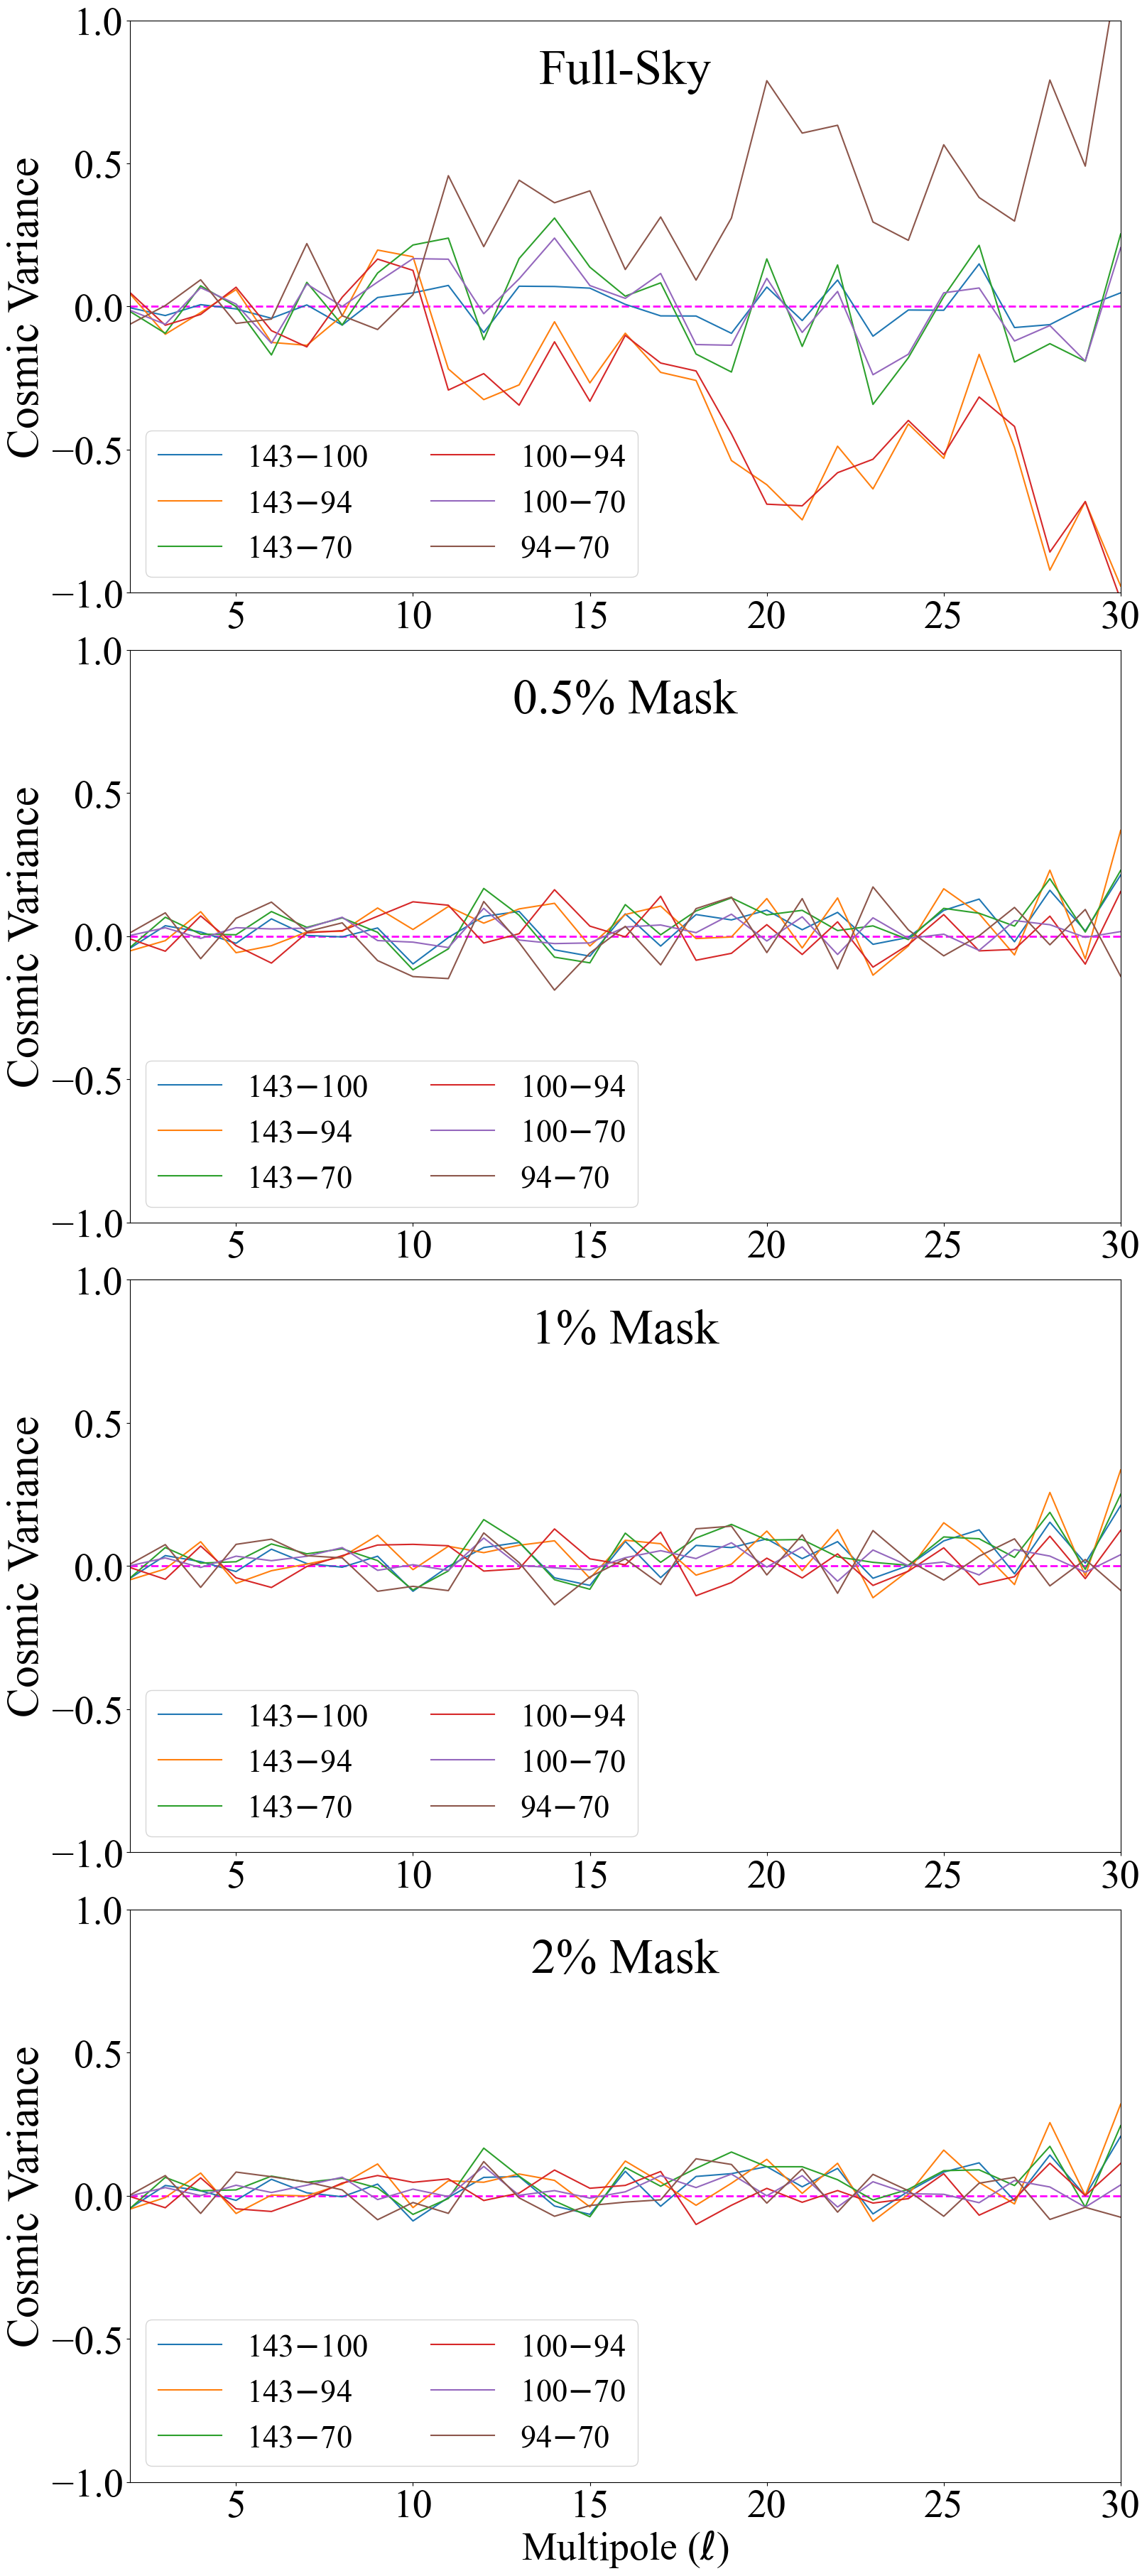

In [17]:
fig, axe = plt.subplots(4, 1, figsize=(18, 45))
plt.subplots_adjust(wspace=0.1, hspace = 0.1)
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 40}) 

axe[0].axhline(y=0, color='magenta', linestyle='--', linewidth=2)
axe[0].plot(ell[valid], ((p143_Cl[valid]-p100_Cl[valid]) / denom[valid]), label='143$-$100')
axe[0].plot(ell[valid], ((p143_Cl[valid]-w94_Cl[valid])/ denom[valid]),label='143$-$94')
axe[0].plot(ell[valid], ((p143_Cl[valid]-p70_Cl[valid])/ denom[valid]),label='143$-$70')
axe[0].plot(ell[valid], ((p100_Cl[valid]-w94_Cl[valid])/ denom[valid]),label='100$-$94')
axe[0].plot(ell[valid], ((p100_Cl[valid]-p70_Cl[valid])/ denom[valid]),label='100$-$70')
axe[0].plot(ell[valid], ((w94_Cl[valid]-p70_Cl[valid])/ denom[valid]),label='94$-$70')
axe[0].text(0.5, 0.95, 'Full-Sky', transform=axe[0].transAxes, fontsize=50, verticalalignment='top', horizontalalignment='center')
axe[0].set_ylabel('Cosmic Variance', fontsize=45)
axe[0].legend(loc = 'lower left',fontsize=32, ncol=2)
axe[0].set_xlim(2, 30)
axe[0].set_ylim(-1,1)

axe[1].axhline(y=0, color='magenta', linestyle='--', linewidth=2)
axe[1].plot(ell[valid], ((Debiased_results['test_143_005p'][valid]-Debiased_results['test_100_005p'][valid])/ denom[valid]), label='143$-$100')
axe[1].plot(ell[valid], ((Debiased_results['test_143_005p'][valid]-Debiased_results['test_94_005p'][valid])/ denom[valid]),label='143$-$94')
axe[1].plot(ell[valid], ((Debiased_results['test_143_005p'][valid]-Debiased_results['test_70_005p'][valid])/ denom[valid]),label='143$-$70')
axe[1].plot(ell[valid], ((Debiased_results['test_100_005p'][valid]-Debiased_results['test_94_005p'][valid])/ denom[valid]),label='100$-$94')
axe[1].plot(ell[valid], ((Debiased_results['test_100_005p'][valid]-Debiased_results['test_70_005p'][valid])/ denom[valid]),label='100$-$70')
axe[1].plot(ell[valid], ((Debiased_results['test_94_005p'][valid]-Debiased_results['test_70_005p'][valid])/ denom[valid]),label='94$-$70')
axe[1].set_ylabel('Cosmic Variance', fontsize=45)
axe[1].legend(loc = 'lower left',fontsize=32, ncol=2)
axe[1].set_xlim(2, 30)
axe[1].set_ylim(-1,1)
axe[1].text(0.5, 0.95, '0.5% Mask', transform=axe[1].transAxes, fontsize=50, verticalalignment='top', horizontalalignment='center')


axe[2].axhline(y=0, color='magenta', linestyle='--', linewidth=2)
axe[2].plot(ell[valid], ((Debiased_results['test_143_01p'][valid]-Debiased_results['test_100_01p'][valid])/ denom[valid]), label='143$-$100')
axe[2].plot(ell[valid], ((Debiased_results['test_143_01p'][valid]-Debiased_results['test_94_01p'][valid])/ denom[valid]),label='143$-$94')
axe[2].plot(ell[valid], ((Debiased_results['test_143_01p'][valid]-Debiased_results['test_70_01p'][valid])/ denom[valid]),label='143$-$70')
axe[2].plot(ell[valid], ((Debiased_results['test_100_01p'][valid]-Debiased_results['test_94_01p'][valid])/ denom[valid]),label='100$-$94')
axe[2].plot(ell[valid], ((Debiased_results['test_100_01p'][valid]-Debiased_results['test_70_01p'][valid])/ denom[valid]),label='100$-$70')
axe[2].plot(ell[valid], ((Debiased_results['test_94_01p'][valid]-Debiased_results['test_70_01p'][valid])/ denom[valid]),label='94$-$70')
axe[2].text(0.5, 0.95, '1% Mask', transform=axe[2].transAxes, fontsize=50, verticalalignment='top', horizontalalignment='center')
axe[2].set_ylabel('Cosmic Variance', fontsize=45)
axe[2].legend(loc = 'lower left',fontsize=32, ncol=2)
axe[2].set_xlim(2, 30)
axe[2].set_ylim(-1,1)

axe[3].axhline(y=0, color='magenta', linestyle='--', linewidth=2)
axe[3].plot(ell[valid], ((Debiased_results['test_143_02p'][valid]-Debiased_results['test_100_02p'][valid])/ denom[valid]), label='143$-$100')
axe[3].plot(ell[valid], ((Debiased_results['test_143_02p'][valid]-Debiased_results['test_94_02p'][valid])/ denom[valid]),label='143$-$94')
axe[3].plot(ell[valid], ((Debiased_results['test_143_02p'][valid]-Debiased_results['test_70_02p'][valid])/ denom[valid]),label='143$-$70')
axe[3].plot(ell[valid], ((Debiased_results['test_100_02p'][valid]-Debiased_results['test_94_02p'][valid])/ denom[valid]),label='100$-$94')
axe[3].plot(ell[valid], ((Debiased_results['test_100_02p'][valid]-Debiased_results['test_70_02p'][valid])/ denom[valid]),label='100$-$70')
axe[3].plot(ell[valid], ((Debiased_results['test_94_02p'][valid]-Debiased_results['test_70_02p'][valid])/ denom[valid]),label='94$-$70')
axe[3].text(0.5, 0.95, '2% Mask', transform=axe[3].transAxes, fontsize=50, verticalalignment='top', horizontalalignment='center')
axe[3].set_xlabel('Multipole ($\ell$)')
axe[3].set_ylabel('Cosmic Variance', fontsize=45)
axe[3].legend(loc = 'lower left',fontsize=32, ncol=2)
axe[3].set_xlim(2, 30)
axe[3].set_ylim(-1,1)